In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("libraries are imported")

libraries are imported


In [9]:
df = pd.read_csv("D:/INTERNSHIP/FUTURE_INTERNS/FUTURE_DS_01/data/raw_data/online_retail.csv", encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df.shape

(541909, 8)

In [12]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [14]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [15]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [16]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 📊 Observations

### 1. Dataset Shape  
The dataset contains **541,909 rows** and **8 columns**, indicating a large-scale transactional dataset suitable for comprehensive analysis.

---

### 2. Column Names  
The dataset includes the following columns:  
- InvoiceNo  
- StockCode  
- Description  
- Quantity  
- InvoiceDate  
- UnitPrice  
- CustomerID  
- Country  

---

### 3. Missing Values  
- The **CustomerID** column contains a significant number of missing values.  
- The **Description** column has a few missing entries.  
- All other columns are relatively complete with minimal or no missing data.  

---

### 4. Data Type Issues  
- The **InvoiceDate** column is not in proper datetime format and requires conversion for time-based analysis.  
- The **CustomerID** column is stored as a numeric datatype but should be treated as a categorical variable.  
- Columns like **InvoiceNo** and **StockCode** are identifiers and should not be used for numerical computations.  

---

### 5. First Impression  
The dataset represents transactional data from an online retail store, containing detailed information about orders, products, pricing, and customers. While the dataset is well-structured, it requires preprocessing steps such as handling missing values, correcting data types, and removing invalid or inconsistent records (e.g., negative quantities or prices). Overall, the dataset is suitable for performing exploratory data analysis, identifying sales patterns, and deriving customer insights.

In [17]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='str')

In [18]:
df.isnull().sum()

invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135080
country             0
dtype: int64

In [27]:
df = df.dropna(subset=["customerid"])

In [28]:
df.isnull().sum()

invoiceno      0
stockcode      0
description    0
quantity       0
invoicedate    0
unitprice      0
customerid     0
country        0
dtype: int64

In [29]:
df = df.drop_duplicates()

In [31]:
df.duplicated().sum()

np.int64(0)

In [34]:

df["invoicedate"] = pd.to_datetime(df["invoicedate"])

In [35]:
df["quantity"] = pd.to_numeric(df["quantity"])
df["unitprice"] = pd.to_numeric(df["unitprice"])

In [36]:
df["sales"] = df["quantity"] * df["unitprice"]

In [37]:
df = df[df["quantity"] > 0]
df = df[df["unitprice"] > 0]

In [43]:
df["year"] = df["invoicedate"].dt.year
df["month"] = df["invoicedate"].dt.month
df["year_month"] = df["invoicedate"].dt.to_period("M").astype(str)

In [45]:
df.to_csv("D:/INTERNSHIP/FUTURE_INTERNS/FUTURE_DS_01/data/processed/cleaned_online_retail.csv", index=False)

In [46]:
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

df["year"] = df["invoicedate"].dt.year
df["month"] = df["invoicedate"].dt.month
df["year_month"] = df["invoicedate"].dt.to_period("M").astype(str)

In [47]:
total_sales = df["sales"].sum()
total_orders = df["invoiceno"].nunique()
total_customers = df["customerid"].nunique()
total_quantity = df["quantity"].sum()
avg_order_value = total_sales / total_orders

kpi = {
    "Total Sales": total_sales,
    "Total Orders": total_orders,
    "Total Customers": total_customers,
    "Total Quantity": total_quantity,
    "Average Order Value": avg_order_value
}

kpi

{'Total Sales': np.float64(8887208.894000001),
 'Total Orders': 18532,
 'Total Customers': 4338,
 'Total Quantity': np.int64(5152002),
 'Average Order Value': np.float64(479.56016047917126)}

## 📊 Business Interpretation

- The total revenue generated is **₹8,887,208.89**, indicating strong overall sales performance of the business.

- The business has **4,338 unique customers**, reflecting a moderately large and diverse customer base.

- A total of **18,532 orders** were placed, showing consistent customer engagement and transaction frequency.

- The average order value (AOV) is **₹479.56**, which provides insight into the typical spending behavior of customers per transaction.

- The combination of a high number of orders and a moderate AOV suggests that customers tend to make **frequent purchases with relatively smaller basket sizes**.

- If the AOV were significantly higher with fewer orders, it would indicate **premium purchasing behavior**, where customers spend more per transaction.

- Overall, the business demonstrates a **balanced sales pattern**, with steady order volume and consistent customer participation, making it suitable for further analysis such as customer segmentation, retention strategies, and sales optimization.

In [48]:
monthly_sales = (
    df.groupby("year_month")["sales"]
    .sum()
    .reset_index()
)

monthly_sales["year_month"] = pd.to_datetime(monthly_sales["year_month"])
monthly_sales = monthly_sales.sort_values("year_month")

monthly_sales

,year_month,sales
0,2010-12-01,570422.730
1,2011-01-01,568101.310
2,2011-02-01,446084.920
3,2011-03-01,594081.760
4,2011-04-01,468374.331
5,2011-05-01,677355.150
6,2011-06-01,660046.050
7,2011-07-01,598962.901
8,2011-08-01,644051.040
9,2011-09-01,950690.202


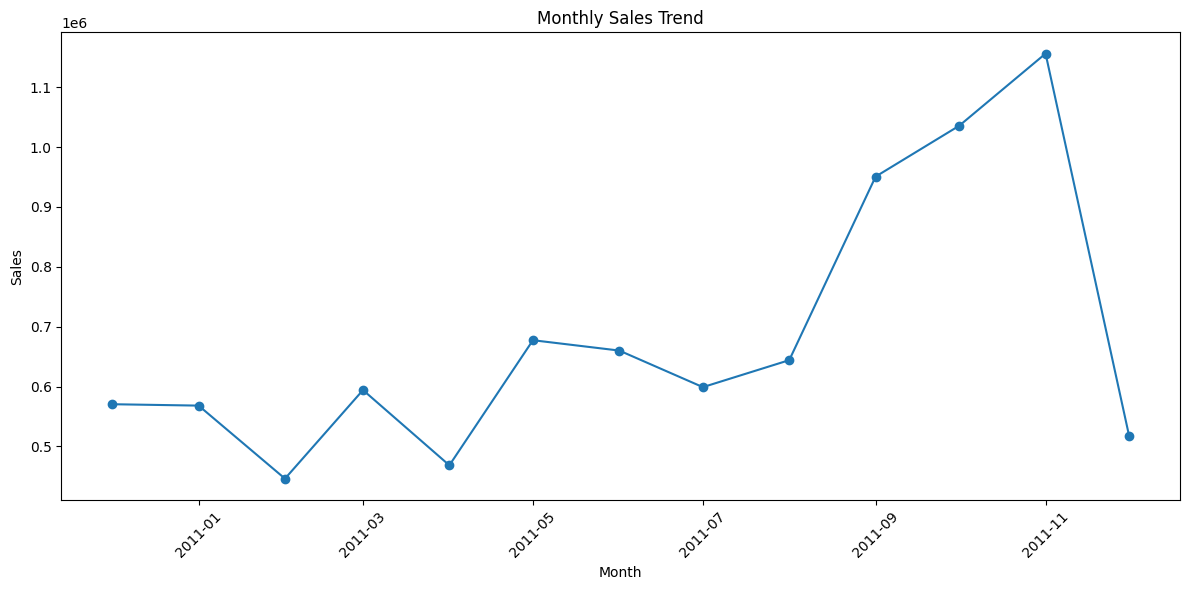

In [49]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales["year_month"], monthly_sales["sales"], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 📈 Monthly Sales Insights

- The **peak sales month is November**, where the business achieved the highest revenue, indicating strong seasonal demand, possibly due to festive or holiday shopping.

- The **lowest sales month is February**, showing a noticeable dip in revenue compared to other months.

- The overall trend shows a **gradual growth throughout the year**, especially from mid-year onwards, followed by a sharp increase in the last quarter.

- The pattern clearly indicates a **seasonal trend**, where sales significantly rise towards the end of the year and drop after the peak period.

- The sharp decline in December after November suggests a **post-peak correction**, which is common after high seasonal demand periods.

- Overall, the business demonstrates **strong seasonal performance**, with peak sales concentrated in the final quarter of the year.

In [50]:
top_products = (
    df.groupby("description")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: sales, dtype: float64

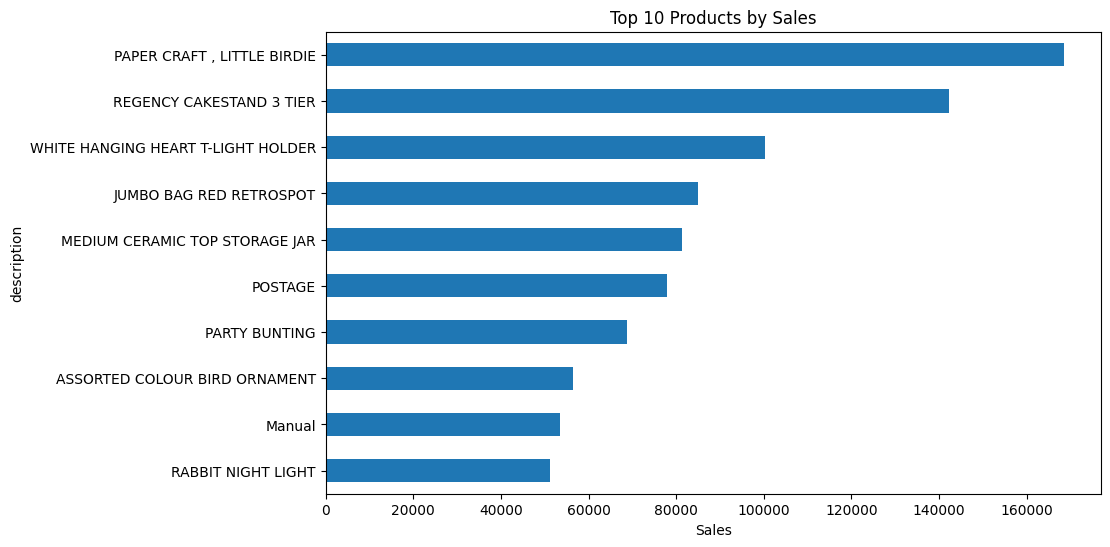

In [51]:
top_products.plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.gca().invert_yaxis()
plt.show()

## 🛍️ Product Sales Insights

- The product **"PAPER CRAFT, LITTLE BIRDIE"** generates the highest revenue (**₹168,469.60**), making it the top-performing product.

- This is followed by **"REGENCY CAKESTAND 3 TIER"** (**₹142,264.75**) and **"WHITE HANGING HEART T-LIGHT HOLDER"** (**₹100,392.10**), indicating that a small group of products contributes significantly to total sales.

- The top 3 products alone account for a **substantial portion of total revenue**, highlighting a strong concentration of sales among a few high-performing items.

- The remaining products show comparatively lower but consistent contributions, indicating a **long-tail distribution** in product sales.

- The business demonstrates a **dependency on a few key products**, which may pose a risk if demand for these products declines.

- At the same time, this concentration provides an opportunity to:
  - Focus on **inventory optimization** for top-selling products  
  - Implement **targeted marketing strategies**  
  - Upsell or cross-sell related products to maximize revenue  

- Overall, while the product portfolio is diverse, revenue is **dominated by a limited number of high-performing products**, suggesting the need for both risk management and strategic scaling.

In [52]:
worst_products = (
    df.groupby("description")["sales"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

worst_products

description
PADS TO MATCH ALL CUSHIONS             0.003
HEN HOUSE W CHICK IN NEST              0.420
SET 12 COLOURING PENCILS DOILEY        0.650
VINTAGE BLUE TINSEL REEL               0.840
PINK CRYSTAL GUITAR PHONE CHARM        0.850
PURPLE FRANGIPANI HAIRCLIP             0.850
CAT WITH SUNGLASSES BLANK CARD         0.950
HAPPY BIRTHDAY CARD TEDDY/CAKE         0.950
60 GOLD AND SILVER FAIRY CAKE CASES    1.100
BLUE LEAVES AND BEADS PHONE CHARM      1.250
Name: sales, dtype: float64

## 📉 Worst Performing Products

- **"PADS TO MATCH ALL CUSHIONS"** shows the lowest sales (**₹0.003**), indicating negligible demand.

- Other products like **"HEN HOUSE W CHICK IN NEST"** and **"SET 12 COLOURING PENCILS DOILEY"** also contribute very low revenue.

- These products have **minimal impact on overall sales** and may require removal or strategy improvement.

In [53]:
country_sales = (
    df.groupby("country")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: sales, dtype: float64

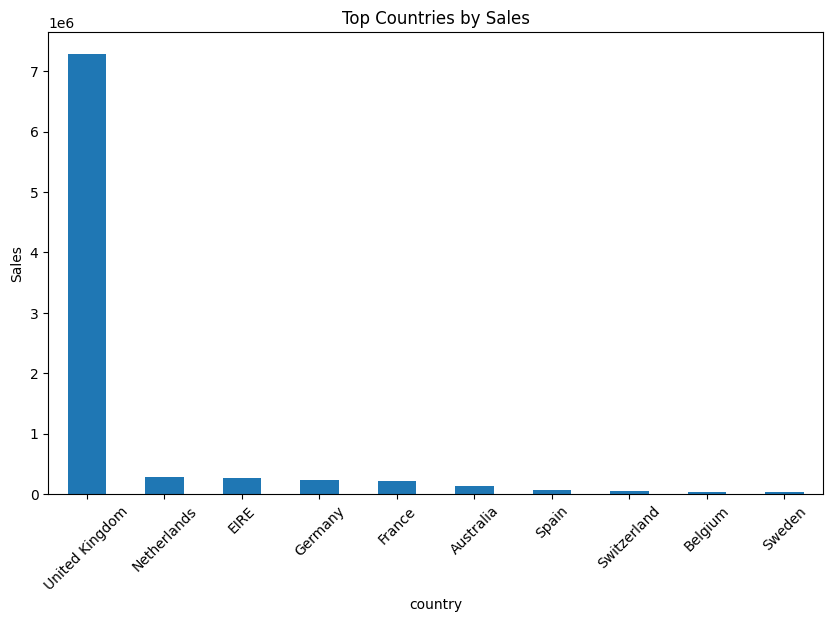

In [54]:
country_sales.plot(kind='bar', figsize=(10,6))
plt.title("Top Countries by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## 🌍 Country-wise Sales Insights

- The **United Kingdom dominates sales** with **₹7,285,024.64**, contributing the majority of total revenue.

- Other countries like **Netherlands, EIRE, and Germany** contribute significantly less in comparison.

- This indicates a strong **dependency on a single market (UK)**, which poses a potential business risk.

- The business should consider **expanding and strengthening other markets** to reduce reliance on one country.

In [55]:
customer_sales = (
    df.groupby("customerid")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_sales

customerid
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: sales, dtype: float64

## 👥 Customer Insights

- A small group of customers contributes a **significant portion of total revenue**, with top customers generating very high sales.

- This indicates that the business is **partially dependent on a few high-value customers**.

- The pattern suggests a mix of **B2B and B2C behavior**, where a few customers place bulk or frequent high-value orders (B2B-like), while others contribute smaller transactions (B2C).

- The business should focus on **retaining high-value customers** while also expanding the broader customer base to reduce dependency risk.

In [56]:
monthly_orders = (
    df.groupby("year_month")["invoiceno"]
    .nunique()
    .reset_index()
)

monthly_orders["year_month"] = pd.to_datetime(monthly_orders["year_month"])
monthly_orders = monthly_orders.sort_values("year_month")

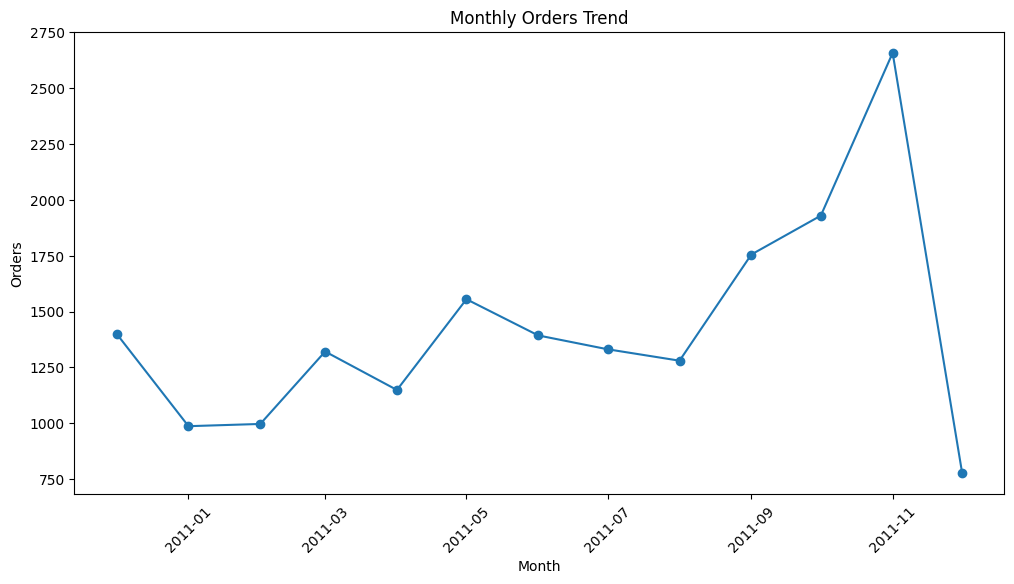

In [57]:
plt.figure(figsize=(12,6))
plt.plot(monthly_orders["year_month"], monthly_orders["invoiceno"], marker='o')
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

## 📦 Monthly Orders Insights

- The **highest number of orders is in November**, indicating peak customer activity during this period.

- The **lowest orders are in December**, showing a sharp drop after the peak month.

- The trend shows a **gradual increase in orders throughout the year**, especially from mid-year onwards.

- This reflects a **seasonal pattern**, with strong growth towards the year-end followed by a post-peak decline.

In [58]:
product_summary = df.groupby("description").agg({
    "sales": "sum",
    "quantity": "sum"
}).reset_index()

product_summary["avg_price"] = product_summary["sales"] / product_summary["quantity"]

product_summary.sort_values("avg_price", ascending=False).head(10)

,description,sales,quantity,avg_price
1036,DOTCOM POSTAGE,11906.36,16,744.147500
2395,PICNIC BASKET WICKER 60 PIECES,39619.50,61,649.500000
2885,RUSTIC SEVENTEEN DRAWER SIDEBOARD,5415.00,35,154.714286
2769,REGENCY MIRROR WITH SHUTTERS,1530.00,10,153.000000
3555,VINTAGE BLUE KITCHEN CABINET,3685.00,26,141.730769
3604,VINTAGE RED KITCHEN CABINET,8125.00,60,135.416667
689,CHEST NATURAL WOOD 20 DRAWERS,2745.00,24,114.375000
1932,LOVE SEAT ANTIQUE WHITE METAL,6210.00,58,107.068966
2920,SCHOOL DESK AND CHAIR,1199.75,19,63.144737
937,DECORATIVE HANGING SHELVING UNIT,359.70,6,59.950000


In [ ]:
monthly_sales.to_csv("../data/processed/monthly_sales.csv", index=False)
country_sales.to_csv("../data/processed/country_sales.csv")
top_products.to_csv("../data/processed/top_products.csv")
product_summary.to_csv("../data/processed/product_summary.csv", index=False)


## 🚀 Advanced Insight: High Sales but Low Quantity Products
- Products like **"DOTCOM POSTAGE"** and **"PICNIC BASKET WICKER 60 PIECES"** generate **high revenue despite low sales volume** due to elevated average prices (₹600–₹740+), indicating a **premium or bulk-purchase segment**.
- This highlights that **revenue is driven by pricing strategy, not just quantity** — making these high-margin products critical for profitability, even with limited customer reach.

## 🔥 Final Business Insights

- Sales show a **strong seasonal pattern**, with peak performance in November and rapid growth in the last quarter, indicating high year-end demand.

- The **United Kingdom dominates revenue**, contributing a major share of total sales, highlighting a strong **geographic dependency risk**.

- Revenue is heavily driven by a **few top-performing products**, indicating **product concentration**, where a limited number of items generate the majority of sales.

- At the same time, several products generate **high revenue with low quantity**, reflecting a **premium pricing strategy** and high-margin opportunities.

- Some products contribute through **high volume but lower value**, indicating a mix of **mass-market (B2C)** and **premium (B2B-like)** sales patterns.

- A small group of **high-value customers contributes significantly to revenue**, showing partial **customer dependency risk**.

- The business demonstrates a **hybrid model (B2B + B2C)**, where bulk buyers and regular customers both play important roles.

- Monthly order trends indicate **consistent growth throughout the year**, followed by a sharp decline after the peak season, suggesting post-season demand correction.

- Certain products show **extremely low or negligible sales**, indicating inefficiencies in inventory and the need for product optimization.

- Overall, the business is **well-performing but highly concentrated** across customers, products, and geography, requiring diversification strategies for long-term stability.

## 💡 Business Recommendations

- Expand operations and marketing efforts in **other countries** to reduce dependency on the UK market and diversify revenue streams.

- Focus marketing and promotions on **high-value (premium) products** to maximize revenue and improve profit margins.

- Introduce **product bundling strategies** for low-value or slow-moving items to increase average order value (AOV).

- Implement **loyalty programs and personalized offers** to retain high-value customers and strengthen long-term relationships.

- Identify **slow-moving or low-performing products** and either remove, discount, or reposition them to optimize inventory.

- Leverage seasonal trends by planning **targeted campaigns before peak months** to maximize sales.

- Improve cross-selling and upselling techniques to **increase basket size per customer**.

- Invest in data-driven marketing to better understand **customer segments (B2B vs B2C)** and tailor strategies accordingly.